In [1]:
'''from pixell.utils.beam_transform_to_profile'''
def beam_transform_to_profile(bl, theta, normalize=False):
    """Given the transform b(l) of a beam, evaluate its real space angular profile
    at the given radii theta."""
    bl = np.asarray(bl)
    l  = np.arange(bl.size)
    x  = np.cos(theta)
    a  = bl*(2*l+1)/(4*np.pi)
    profile = np.polynomial.legendre.legval(x,a)
    if normalize: profile /= np.sum(a)
    return profile

In [4]:
import numpy as np

# Define the file path
home = '/Users/yi/Documents/CMB_SZ/act_dr5/beams/'

# Define the frequencies you want to loop through
frequencies = [90, 150, 220]
beam_profile_list = []
# Create a loop to go through each frequency
for freq in frequencies:
    # Generate the file name based on the current frequency
    beam_file = home + f'act_planck_dr5.01_s08s18_f{freq:03d}_daynight_beam.txt'
    
    # Load the data
    beam_data = np.genfromtxt(beam_file)
    
    # Extract ell and beam values
    ell = beam_data[:, 0]
    beam_ell = beam_data[:, 1]
    
    # Calculate theta values
    theta_arcmin = np.linspace(0, 20, 1000)  # arcmin
    theta_rad = theta_arcmin / 60.0 * (np.pi / 180)  # radians
    
    # Transform beam to profile
    beam_profile = beam_transform_to_profile(beam_ell, theta_rad)
    beam_profile_list.append(beam_profile)
    


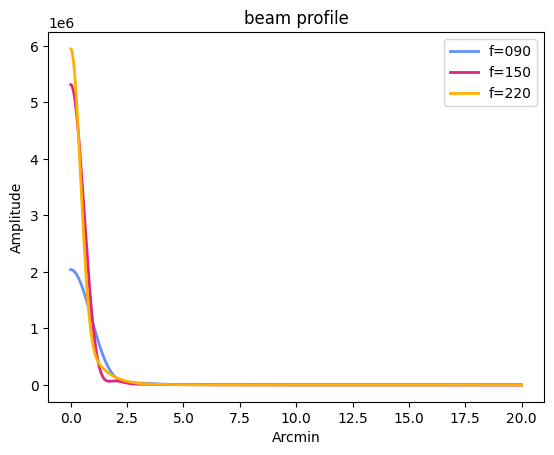

In [12]:
cosmology_palette = ['#648FFF', '#DC267F', '#FFB000']  

plt.plot(theta_arcmin, beam_profile_list[0], label='f=090', color=cosmology_palette[0], linewidth=2)  # Line 1
plt.plot(theta_arcmin, beam_profile_list[1], label='f=150', color=cosmology_palette[1], linewidth=2)  # Line 2
plt.plot(theta_arcmin, beam_profile_list[2], label='f=220', color=cosmology_palette[2], linewidth=2)  # Line 3

# Adding title and labels
plt.title('beam profile')
plt.xlabel('Arcmin')
plt.ylabel('Amplitude')
#plt.yscale("log")
# Adding legend
plt.legend()

# Show plot
plt.show()

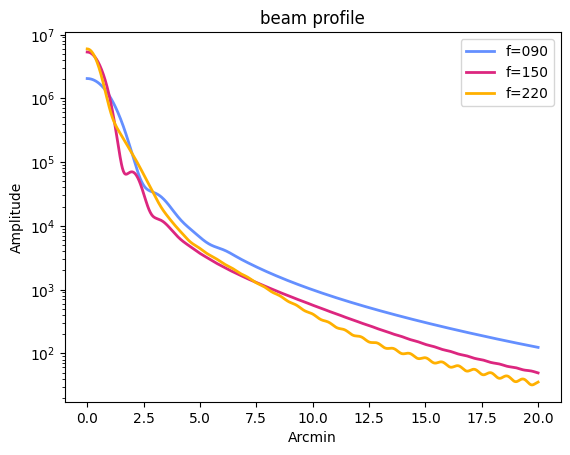

In [13]:
cosmology_palette = ['#648FFF', '#DC267F', '#FFB000']  

plt.plot(theta_arcmin, beam_profile_list[0], label='f=090', color=cosmology_palette[0], linewidth=2)  # Line 1
plt.plot(theta_arcmin, beam_profile_list[1], label='f=150', color=cosmology_palette[1], linewidth=2)  # Line 2
plt.plot(theta_arcmin, beam_profile_list[2], label='f=220', color=cosmology_palette[2], linewidth=2)  # Line 3

# Adding title and labels
plt.title('beam profile')
plt.xlabel('Arcmin')
plt.ylabel('Amplitude')
plt.yscale("log")
# Adding legend
plt.legend()

# Show plot
plt.show()